# Lecture09

In this assignment you will work with the basic building blocks of PyTorch, including tensors and autograd. To start with this will be very  low-level PyTorch, in future lectures we will get into the higher-level functionality of PyTorch which make it really easy to build and train neural networks.

In [1]:
import torch
print(torch.__version__)
import numpy as np
import matplotlib.pyplot as plt

# !pip install torchviz
from torchviz import make_dot

2.14.0+cu130


## Initializing tensors

### Tensor from Data

In [2]:
scalar = torch.tensor(5.)
vector = torch.tensor([5,4,3,2,1])
matrix = torch.tensor([[1,2,3],[4,5,6],[7,8,9]])

print(scalar)
print(vector)
print(matrix)

tensor(5.)
tensor([5, 4, 3, 2, 1])
tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])


### Tensor from NumPy

If you have data in a NumPy array, you can convert it to a PyTorch tensor using `torch.from_numpy`

In [3]:
data_np = np.array([[2,5],[6,4]])
x_data = torch.from_numpy(data_np)

print(f'data_np:\n {data_np}')
print(f'x_data:\n {x_data}')

data_np:
 [[2 5]
 [6 4]]
x_data:
 tensor([[2, 5],
        [6, 4]])


### Random Tensor

The weights of a neural network are initalized with random values. PyTorch has `torch.rand` and `torch.randn` functions for generating random tensors with a specified size. For example `torch.rand(2,3)` will crate a tensor with size $2\times3$ (2 rows, 3 columns). Below, create two tensors each with size $1000\times500$, using `torch.rand` for one, and `torch.randn` for the other. After the tensors are initialized, plot histograms to show the distributions of each tensor.

Text(0.5, 1.0, 'torch.randn')

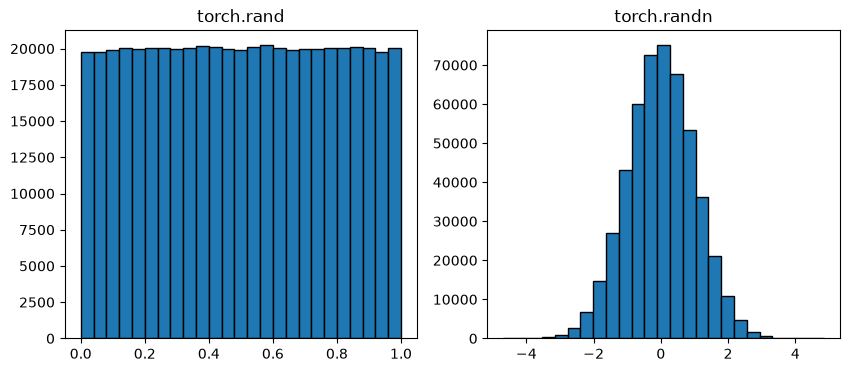

In [4]:
rand_tensor = torch.rand(1000,500)
randn_tensor = torch.randn(1000,500)

fig, ax = plt.subplots(1,2, figsize = (10,4))
_ = ax[0].hist(torch.flatten(rand_tensor),bins=25,edgecolor='k')
_ = ax[1].hist(torch.flatten(randn_tensor),bins=25,edgecolor='k')
ax[0].set_title("torch.rand")
ax[1].set_title("torch.randn")


After viewing the histograms, what do you notice about the two distributions? What is the difference between `torch.rand` and `torch.randn`

### ANSWER: torch.rand provides a uniform distribution, whereas torch.randn provides a standard norm distribution. Additionally, the value ranges differs between the two, as the prior lies between 0 to 1, where the latter is symmetric from -3 to 3 (x-axis)

## Autograd

PyTorch provides automatic differentiation (autograd) functionality, enabling gradients to be tracked on tensor operations. 

Given the function

$$f = (x+y)\times z$$

with $x=5$, $y=-2$, $z=4$, use autograd to compute 

$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \\ \frac{\partial f}{\partial z}  \end{bmatrix}$$

First, create and initalize tensors for $x$, $y$, $z$. Since the goal is to compute $\nabla f$, make sure to use `requires_grad=True`.

In [5]:
x = torch.tensor(5., requires_grad=True)
y = torch.tensor(-2., requires_grad=True)
z = torch.tensor(4., requires_grad=True)


Note you can pass the `requires_grad=True` when creating a tensor **or** modify the `requires_grad` attribute after the tensor is created using the `requires_grad_(True)` member function of a tensor. Note pytorch uses the underscore at the end of a function for in-place operations.

In [6]:
x.requires_grad_(True)

tensor(5., requires_grad=True)

Write the expression to compute $f$ using operations on the above tensors, i.e., the forward pass.


In [7]:
f = (x+y)*z
print(f)

tensor(12., grad_fn=<MulBackward0>)


All tensors with `requires_grad=True` will have a `grad` attribute the gradient with respect to that tensor. Below try printing the `grad` value for each tensor.

In [9]:
print(x.grad)
print(y.grad)
print(z.grad)

None
None
None


Currently, no values are stored in the `grad` attributes. The function $f$ has been evaluated (i.e., forward pass), however, the backward pass (which calculates gradients) has not been executed. The backward pass is executed by calling `backward()` on the tensor for which you are computing the gradient on. Here we want to take $\nabla f$ so we call `f.backward()`

In [8]:
f.backward()

print(x.grad)
print(y.grad)
print(z.grad)

tensor(4.)
tensor(4.)
tensor(3.)


/home/iabney/.local/lib/python3.11/site-packages/torch/autograd/graph.py:1072: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Gradients are **accumulated** with each call of `backward()`. To see this, run the forward and backward pass again and print the gradient values:

In [9]:
f = (x+y)*z
f.backward()

print(x.grad)
print(y.grad)
print(z.grad)

tensor(8.)
tensor(8.)
tensor(6.)


Typically, for training neural networks this is not the desired behavior. We want to use the gradients of only the current step, we do not want accumulate gradients over all steps. Therefore, it is neccessary to zero the gradients after each pass. Forgetting this is a common bug.

In [10]:
x.grad.zero_()
y.grad.zero_()
z.grad.zero_()

print(x.grad)
print(y.grad)
print(z.grad)


tensor(0.)
tensor(0.)
tensor(0.)


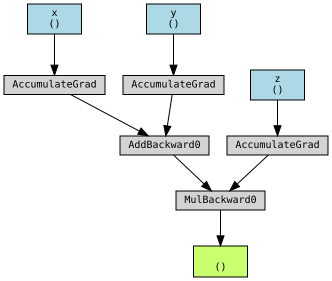

In [11]:
params = dict(x = x, y = y, z = z)
make_dot(f, params = params)

## Practice problems

For each practice problem:

- Create and intiizlize input tensors
- Evaluate function (forward pass)
- Perform backward pass
- Report gradients


### Problem 1

Given the function

$$f(x,y) = \sqrt{x^2 + y^2}$$

Compute 
$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix}$$

Assume $x=4$, $y=3$


In [14]:
x = torch.tensor(4., requires_grad=True)
y = torch.tensor(3., requires_grad=True)

f = torch.sqrt(((x*x) + (y*y)))
print(f)
f.backward()

print(x.grad)
print(y.grad)

x.grad.zero_()
y.grad.zero_()

tensor(5., grad_fn=<SqrtBackward0>)
tensor(0.8000)
tensor(0.6000)


tensor(0.)

### Problem 2

Given the function

$$f(a,x) = e^{-(ax)}$$

Compute 
$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial a} \\ \frac{\partial f}{\partial x} \end{bmatrix}$$

Assume $a=2$, $x=-0.5$

In [18]:
x1 = torch.tensor(-0.5, requires_grad=True)
a = torch.tensor(2., requires_grad=True)

f1 = torch.exp(-(a*x1))
print(f1)

f1.backward()

print(x1.grad)
print(a.grad)

x1.grad.zero_()
a.grad.zero_()

tensor(2.7183, grad_fn=<ExpBackward0>)
tensor(-5.4366)
tensor(1.3591)


tensor(0.)

### Problem 3

Given the function

$$f(x,y,z) = \frac{xy}{z}$$

Compute 
$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \\ \frac{\partial f}{\partial z} \end{bmatrix}$$

Assume $x=6$, $y=3$, $z=9$

In [20]:
x2 = torch.tensor(6., requires_grad=True)
y2 = torch.tensor(3., requires_grad=True)
z1 = torch.tensor(9., requires_grad=True)

f2 = (x2*y2) / z1

print(f2)

f2.backward()

print(x2.grad)
print(y2.grad)
print(z1.grad)

x.grad.zero_()
y.grad.zero_()
z.grad.zero_()

tensor(2., grad_fn=<DivBackward0>)
tensor(0.3333)
tensor(0.6667)
tensor(-0.2222)


tensor(0.)

### Problem 4

Given the function

$$f(a,b,w_0, w_1, x_0, x_1) = a \mathrm{ReLU}(w_0x_0) + \mathrm{ReLU}(w_1x_1) - b$$

Compute
$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial a} \\ \frac{\partial f}{\partial b} \\ \frac{\partial f}{\partial w_0} \\ \frac{\partial f}{\partial w_1} \\ \frac{\partial f}{\partial x_0} \\ \frac{\partial f}{\partial x_1}\end{bmatrix}$$

Assume $a=2$, $b=6$, $w_0=3$,  $w_1=5$, $x_0=4$, $x_1=-2$

In [21]:
a2 = torch.tensor(2., requires_grad=True)
b2 = torch.tensor(6., requires_grad=True)
w0 = torch.tensor(3., requires_grad=True)
w1 = torch.tensor(5., requires_grad=True)
x0 = torch.tensor(4., requires_grad=True)
x3 = torch.tensor(-2., requires_grad=True)

f4 = a2*torch.relu(w0*x0) + torch.relu(w1*x3) - b2

print(f4)

f4.backward()

print(a2.grad)
print(b2.grad)
print(w0.grad)
print(w1.grad)
print(x0.grad)
print(x3.grad)

a2.grad.zero_()
b2.grad.zero_()
w0.grad.zero_()
w1.grad.zero_()
x0.grad.zero_()
x3.grad.zero_()

tensor(18., grad_fn=<SubBackward0>)
tensor(12.)
tensor(-1.)
tensor(8.)
tensor(-0.)
tensor(6.)
tensor(0.)


tensor(0.)

### Problem 5

Given the function

$$f = ax^2 + bxy$$

compute 

$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial a} \\ \frac{\partial f}{\partial b} \\ \frac{\partial f}{\partial x} \\ \frac{\partial f}{\partial y} \end{bmatrix}$$

Assume $a=2$, $b=4$, $x=3$, $y=5$


In [22]:
a3 = torch.tensor(2., requires_grad=True)
b3 = torch.tensor(4., requires_grad=True)
x5 = torch.tensor(3., requires_grad=True)
y5 = torch.tensor(5., requires_grad=True)


f5 = a3*(x5*x5) + b3*x5*y5

print(f5)

f5.backward()

print(a3.grad)
print(b3.grad)
print(x5.grad)
print(y5.grad)


a3.grad.zero_()
b3.grad.zero_()
x5.grad.zero_()
y5.grad.zero_()


tensor(78., grad_fn=<AddBackward0>)
tensor(9.)
tensor(15.)
tensor(32.)
tensor(12.)


tensor(0.)

Save a PDF of the document to upload to ICON and then add/commit/push to your git repository.